In [8]:
# Model 1: Logistic Regression
import pandas as pd
import numpy as np

# Load the feature-engineered, preprocessed data saved earlier
X_train = pd.read_csv("../data/processed_fe/X_train_balanced.csv")
y_train = pd.read_csv("../data/processed_fe/y_train_balanced.csv").values.ravel()
X_test = pd.read_csv("../data/processed_fe/X_test.csv")
y_test = pd.read_csv("../data/processed_fe/y_test.csv").values.ravel()

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Training fraud cases:", int(y_train.sum()))
print("Test fraud cases:", int(y_test.sum()))

Training set: (454902, 31)
Test set: (56962, 31)
Training fraud cases: 227451
Test fraud cases: 98


In [9]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
# max_iter=1000 gives the model enough iterations to converge on this data 
# random_state=42 makes the result reproducible
model_lr = LogisticRegression(max_iter=1000, random_state=42)

# Train (fit) the model on the balanced training data
model_lr.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [10]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

# Use the trained model to predict on the UNTOUCHED test set
y_pred = model_lr.predict(X_test)

# Also get the predicted probabilities (needed for ROC-AUC and PR-AUC)
y_pred_proba = model_lr.predict_proba(X_test)[:, 1]

# Print the classification report (precision, recall, f1 for each class)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"]))

# Print the two key metrics for imbalanced data
print("ROC-AUC score:", round(roc_auc_score(y_test, y_pred_proba), 4))
print("PR-AUC score:", round(average_precision_score(y_test, y_pred_proba), 4))

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC score: 0.9705
PR-AUC score: 0.7236


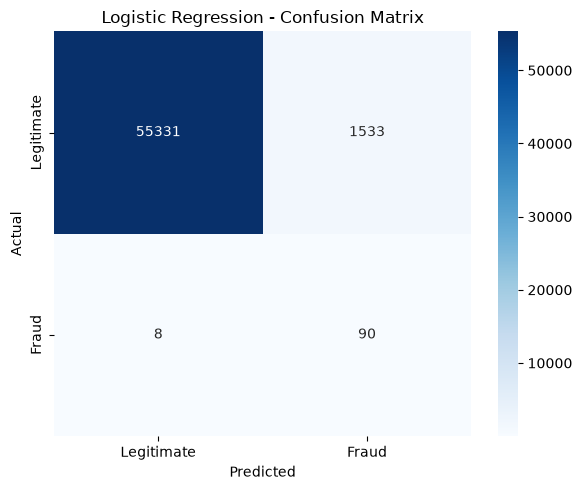

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Build the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legitimate", "Fraud"],
            yticklabels=["Legitimate", "Fraud"])
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()